In [38]:
!pip install kaggle xgboost lightgbm catboost imbalanced-learn scikit-learn seaborn matplotlib plotly --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, cohen_kappa_score
)

In [39]:
from google.colab import drive
drive.mount('/content/drive')
csv_files = glob.glob('/content/drive/MyDrive/CI/networkanomalydataset.csv', recursive=True)
if csv_files:
    print('\nFound CSV files:', csv_files)
    df = pd.read_csv(csv_files[0])
    print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
else:
    print(' No CSV files found in the specified Drive path.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Found CSV files: ['/content/drive/MyDrive/CI/networkanomalydataset.csv']
Dataset loaded: 1,654 rows × 5 columns


In [41]:
df = pd.read_csv('/content/drive/MyDrive/CI/networkanomalydataset.csv')

In [42]:
df_clean = df.copy()

print('=' * 60)
print('DATASET OVERVIEW (BEFORE CLEANING)')
print('=' * 60)
print(f'Initial Shape : {df_clean.shape}')
print(f'Missing Values: {df_clean.isnull().sum().sum()}')
print(f'Duplicates    : {df_clean.duplicated().sum():,}')

df_clean.drop_duplicates(inplace=True)
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

print('\n' + '=' * 60)
print('DATASET OVERVIEW (AFTER CLEANING)')
print('=' * 60)
print(f'Cleaned Shape : {df_clean.shape}')
print('\n')

DATASET OVERVIEW (BEFORE CLEANING)
Initial Shape : (1654, 5)
Missing Values: 0
Duplicates    : 0

DATASET OVERVIEW (AFTER CLEANING)
Cleaned Shape : (1654, 5)




In [43]:
print('\n--- First 5 Rows ---')
display(df_clean.head())
print('\n--- Statistical Summary ---')
df.describe(include='all')


--- First 5 Rows ---


,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
0,0.931000,1.224246,0.931001,1.224244,0
1,0.965773,1.302733,0.965944,1.303585,0
2,1.018103,1.341763,1.017932,1.342183,0
3,1.088629,1.374144,1.088671,1.374348,0
4,1.128772,1.381435,1.128727,1.380781,0



--- Statistical Summary ---


,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
count,1.654000e+03,1.654000e+03,1.654000e+03,1.654000e+03,1654.000000
mean,1.374690e-16,-1.374690e-16,-6.873448e-17,2.062035e-16,0.500000
std,1.000302e+00,1.000302e+00,1.000302e+00,1.000302e+00,0.500151
min,-8.587873e-01,-8.451589e-01,-8.587677e-01,-8.450422e-01,0.000000
25%,-8.071507e-01,-8.063695e-01,-8.072172e-01,-8.064441e-01,0.000000
50%,-7.555341e-01,-7.747574e-01,-7.554490e-01,-7.751713e-01,0.500000
75%,9.628647e-01,1.112895e+00,9.627478e-01,1.112738e+00,1.000000
max,2.122913e+00,1.997753e+00,2.122901e+00,1.998350e+00,1.000000


 Target column identified: "Label"
Distribution:
Label
0    827
1    827
Name: count, dtype: int64


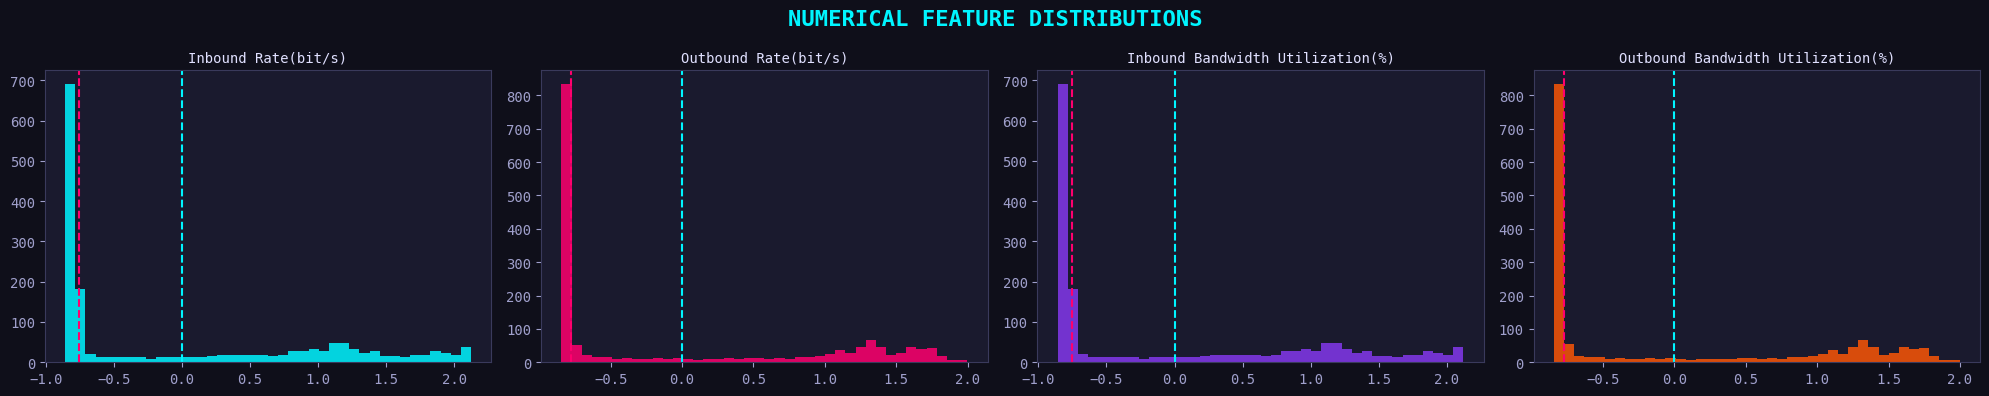

In [44]:

possible_targets = ['label', 'Label', 'class', 'Class', 'attack', 'Attack', 'anomaly']
target_col = next((col for col in possible_targets if col in df_clean.columns), df_clean.columns[-1])

print(f' Target column identified: "{target_col}"')
print(f'Distribution:\n{df_clean[target_col].value_counts()}')

num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

show_cols = num_cols[:20]
n_cols_plot = 4
n_rows_plot = (len(show_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, n_rows_plot * 4))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('NUMERICAL FEATURE DISTRIBUTIONS', fontsize=16, color='#00f5ff', fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(show_cols):
    axes[i].hist(df_clean[col], bins=40, color=PALETTE[i % len(PALETTE)], edgecolor='none', alpha=0.85)
    axes[i].set_title(col, color='#e0e0ff', fontsize=10)
    axes[i].axvline(df_clean[col].mean(), color='#00f5ff', linestyle='--', lw=1.5)
    axes[i].axvline(df_clean[col].median(), color='#ff006e', linestyle='--', lw=1.5)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

 Target Column identified as: 'Label'
Generating EDA plots for the top numerical features...


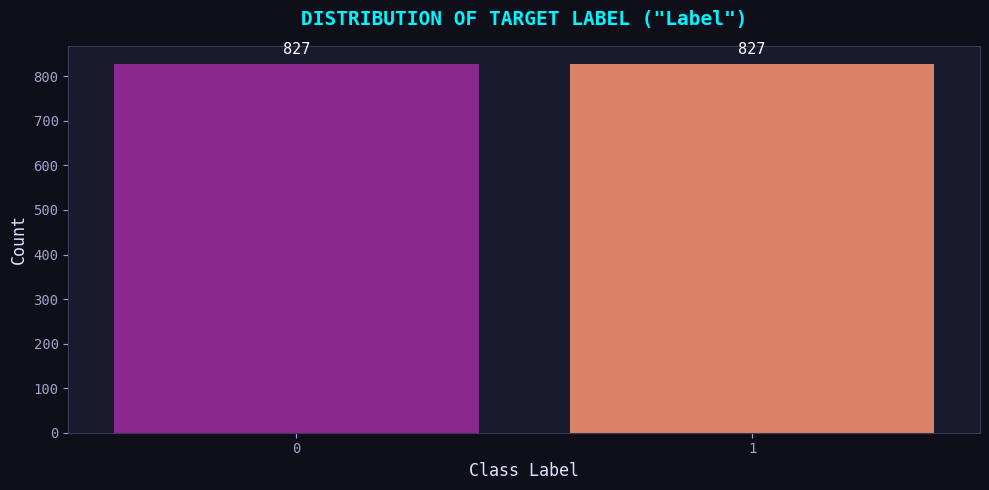

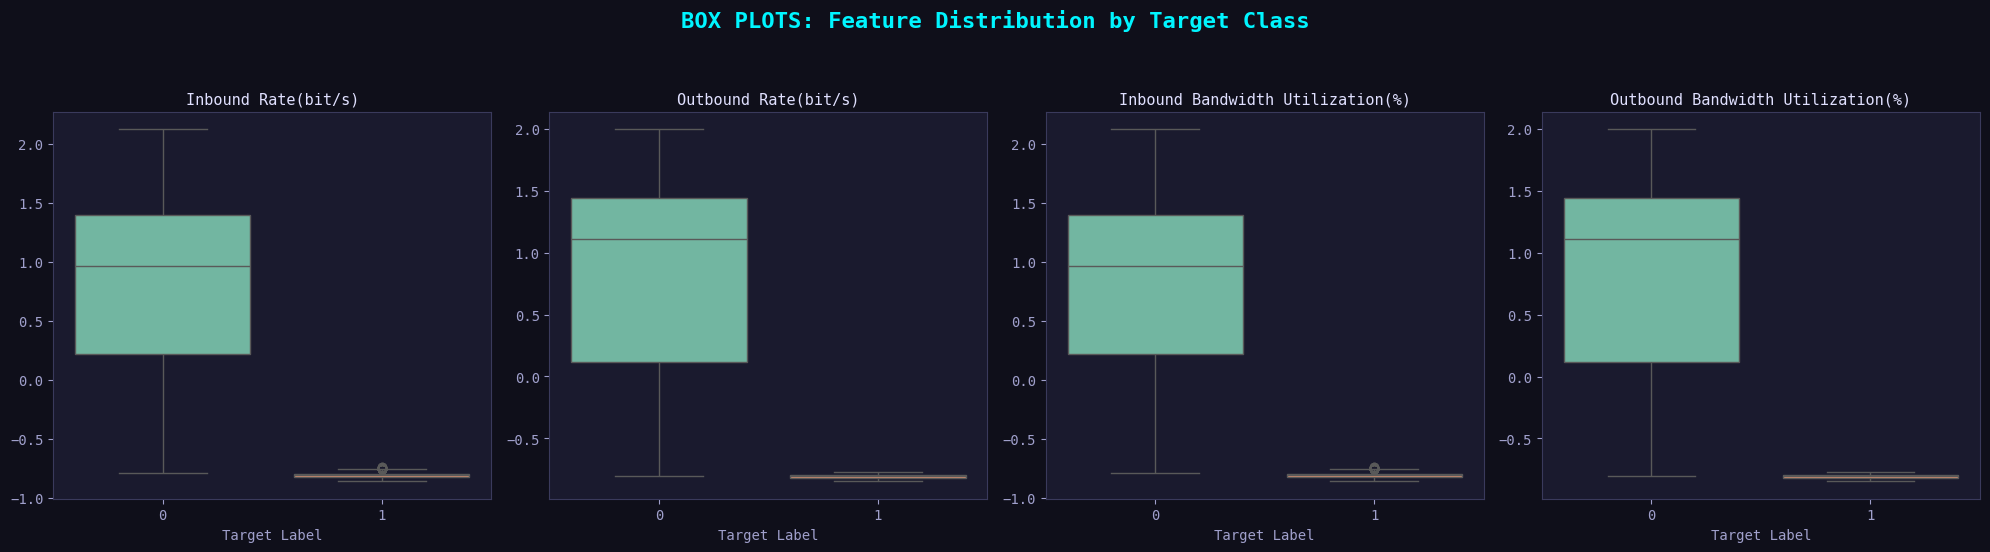

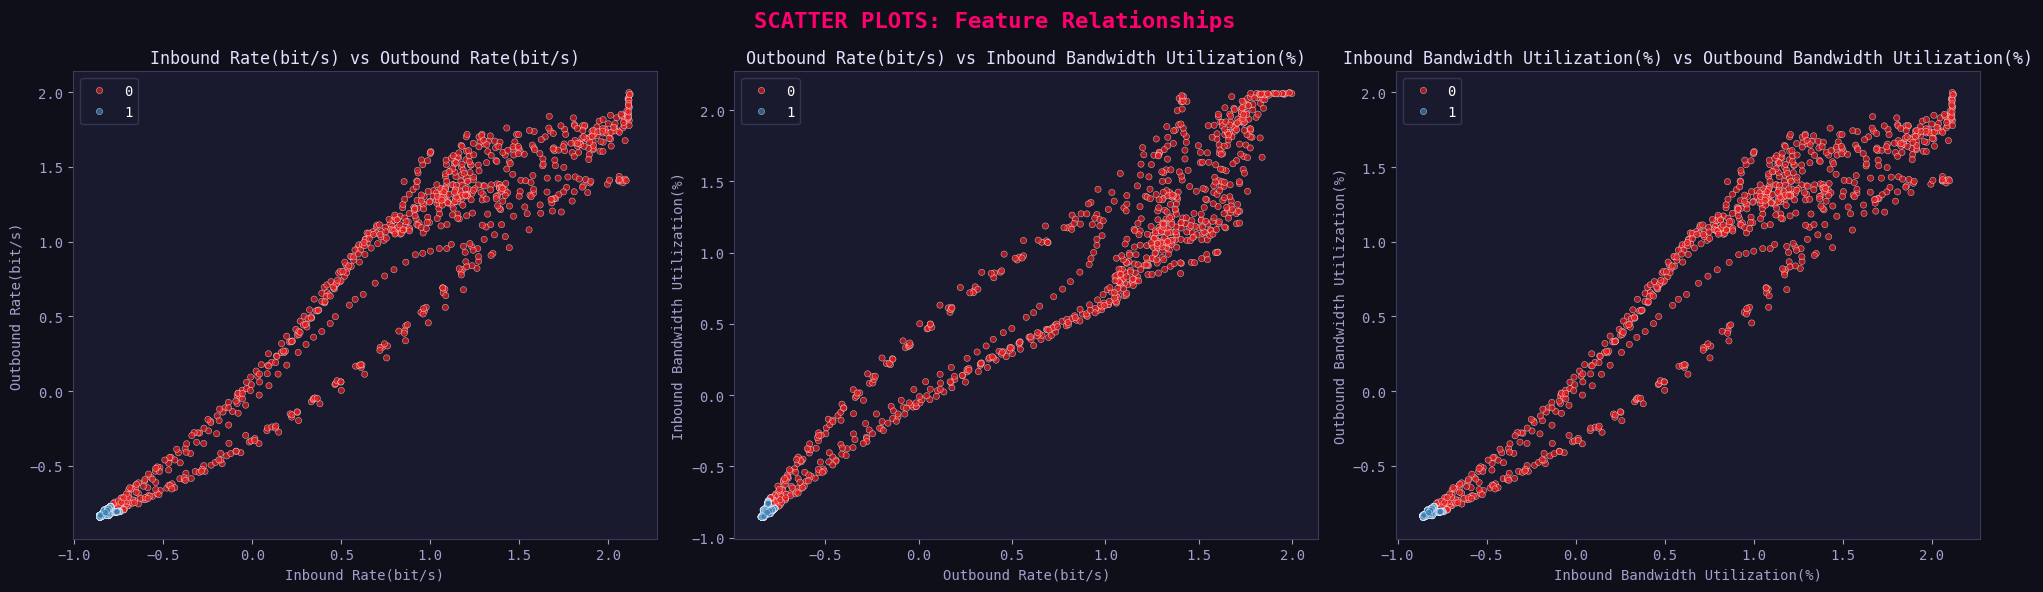

 Unified EDA visual dashboard generated successfully!


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

print(f" Target Column identified as: '{target_col}'")
print(f"Generating EDA plots for the top numerical features...")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

sns.countplot(x=target_col, data=df, palette='plasma', ax=ax)
ax.set_title(f'DISTRIBUTION OF TARGET LABEL ("{target_col}")', color='#00f5ff', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Class Label', color='#e0e0ff', fontsize=12)
ax.set_ylabel('Count', color='#e0e0ff', fontsize=12)
ax.tick_params(colors='#a0a0cc')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', color='white', fontsize=11, xytext=(0, 5),
                textcoords='offset points')

for spine in ax.spines.values():
    spine.set_color('#3a3a5c')

plt.tight_layout()
plt.show()


features_to_plot = num_cols[:8]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('BOX PLOTS: Feature Distribution by Target Class', fontsize=16, color='#00f5ff', fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x=target_col, y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col, color='#e0e0ff', fontsize=11)
    axes[i].set_facecolor('#1a1a2e')
    axes[i].tick_params(colors='#a0a0cc')
    axes[i].set_xlabel('Target Label', color='#a0a0cc')
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_color('#3a3a5c')


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('SCATTER PLOTS: Feature Relationships', fontsize=16, color='#ff006e', fontweight='bold')

scatter_pairs = [(0, 1), (1, 2), (2, 3)]

for i, (idx1, idx2) in enumerate(scatter_pairs):
    if idx2 < len(num_cols):
        sns.scatterplot(
            x=num_cols[idx1],
            y=num_cols[idx2],
            hue=target_col,
            data=df,
            ax=axes[i],
            palette='Set1',
            alpha=0.7,
            s=20
        )
        axes[i].set_title(f'{num_cols[idx1]} vs {num_cols[idx2]}', color='#e0e0ff', fontsize=12)
        axes[i].set_facecolor('#1a1a2e')
        axes[i].tick_params(colors='#a0a0cc')
        axes[i].xaxis.label.set_color('#a0a0cc')
        axes[i].yaxis.label.set_color('#a0a0cc')

        for spine in axes[i].spines.values():
            spine.set_color('#3a3a5c')

        legend = axes[i].legend(facecolor='#1a1a2e', edgecolor='#3a3a5c', labelcolor='white')

plt.tight_layout()
plt.show()

print(' Unified EDA visual dashboard generated successfully!')

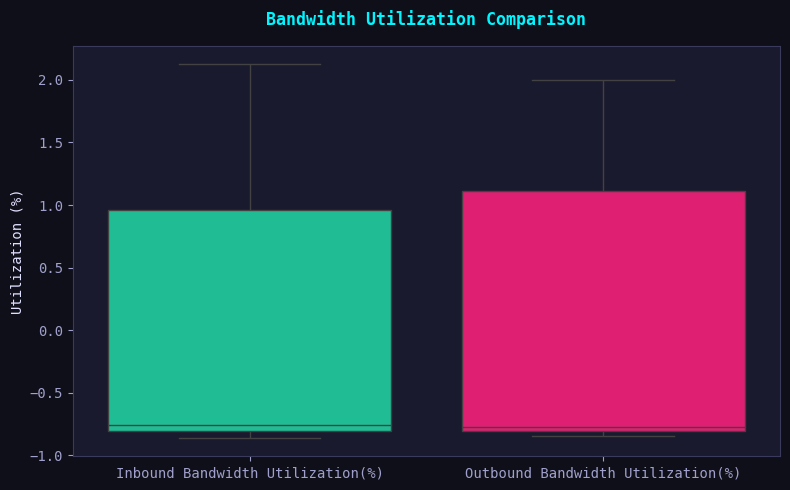

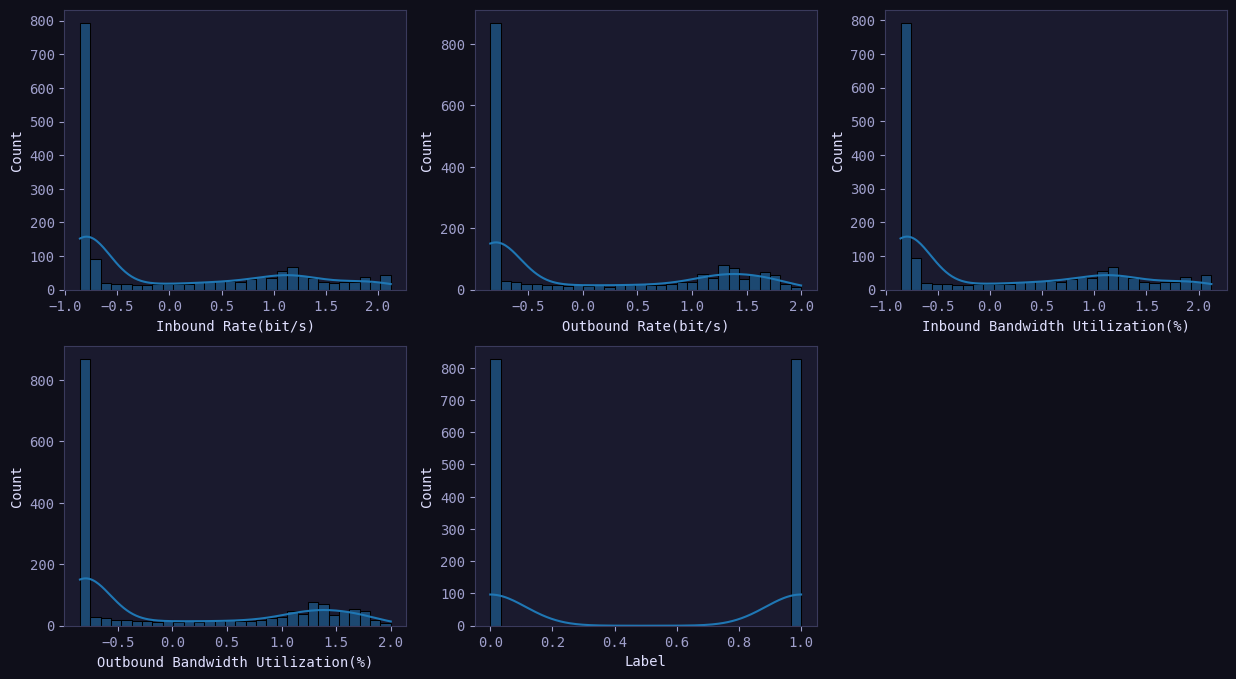

In [46]:
col1 = 'Inbound Bandwidth Utilization(%)'
col2 = 'Outbound Bandwidth Utilization(%)'

if col1 in df.columns and col2 in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#1a1a2e')

    sns.boxplot(data=df[[col1, col2]], palette=['#06d6a0','#ff006e'], ax=ax)

    ax.set_title("Bandwidth Utilization Comparison", color='#00f5ff', fontweight='bold', pad=15)
    ax.set_ylabel("Utilization (%)", color='#e0e0ff')
    ax.tick_params(colors='#a0a0cc')

    for spine in ax.spines.values():
        spine.set_color('#3a3a5c')

    plt.tight_layout()
    plt.show()
else:
    print(f" Skipping Bandwidth comparison: Columns not found in dataset.")
import math

def plot_all_hist(df,title_prefix=""):
    cols = df.columns
    n_cols = 3
    n_rows = math.ceil(len(cols)/n_cols)

    plt.figure(figsize=(5*n_cols,4*n_rows))
    for i, col in enumerate(cols,1):
        plt.subplot(n_rows,n_cols,i)
        sns.histplot(df[col],kde=True,bins=30)
    plt.show()
plot_all_hist(df)


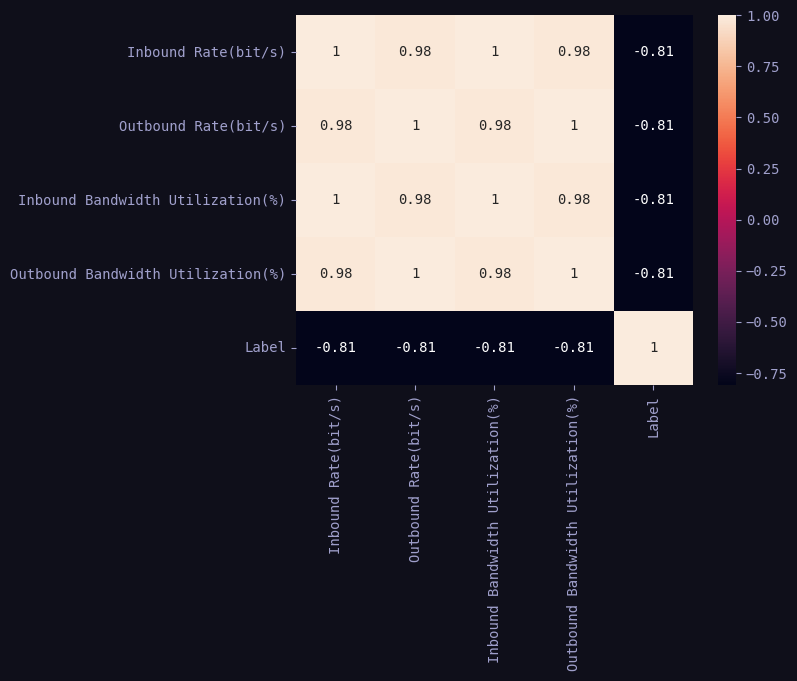

In [47]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [48]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].astype(int)
is_binary = len(np.unique(y)) == 2

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train set      : {X_train.shape} (70%)')
print(f'Validation set : {X_val.shape} (15%)')
print(f'Test set       : {X_test.shape} (15%)')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

try:
    X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train_sc, y_train)
    print(f'Train set after SMOTE: {X_train_res.shape}')
except Exception as e:
    print('SMOTE skipped, using original data.')
    X_train_res, y_train_res = X_train_sc, y_train

print('\n Preprocessing Complete!')

Train set      : (1157, 4) (70%)
Validation set : (248, 4) (15%)
Test set       : (249, 4) (15%)
Train set after SMOTE: (1158, 4)

 Preprocessing Complete!


In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time
import numpy as np

print('=' * 80)
print('SUPERVISED MODEL TRAINING (TRAIN vs VAL & CROSS-VALIDATION)')
print('=' * 80)

n_classes = len(np.unique(y))
multi_avg = 'binary' if is_binary else 'weighted'

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
    'AdaBoost'            : AdaBoostClassifier(random_state=42, algorithm='SAMME'),
    'XGBoost'             : XGBClassifier(random_state=42, n_jobs=-1),
    'LightGBM'            : LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'Linear SVM (Soft)'   : LinearSVC(C=1.0, random_state=42, dual=False),
    'Linear SVM (Hard)'   : LinearSVC(C=1e10, random_state=42, dual=False),
    'Perceptron'          : Perceptron(random_state=42)
}

results = {}
trained_models = {}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    start_time = time.time()


    model.fit(X_train_res, y_train_res)
    trained_models[name] = model

    train_preds = model.predict(X_train_res)
    train_acc  = accuracy_score(y_train_res, train_preds)
    train_prec = precision_score(y_train_res, train_preds, average=multi_avg, zero_division=0)
    train_rec  = recall_score(y_train_res, train_preds, average=multi_avg, zero_division=0)
    train_f1   = f1_score(y_train_res, train_preds, average=multi_avg, zero_division=0)

    val_preds = model.predict(X_val_sc)
    val_acc  = accuracy_score(y_val, val_preds)
    val_prec = precision_score(y_val, val_preds, average=multi_avg, zero_division=0)
    val_rec  = recall_score(y_val, val_preds, average=multi_avg, zero_division=0)
    val_f1   = f1_score(y_val, val_preds, average=multi_avg, zero_division=0)

    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='f1_weighted', n_jobs=-1)

    train_time = round(time.time() - start_time, 2)

    results[name] = {
        'Train Acc' : round(train_acc, 4),  'Val Acc' : round(val_acc, 4),
        'Train Prec': round(train_prec, 4), 'Val Prec': round(val_prec, 4),
        'Train Rec' : round(train_rec, 4),  'Val Rec' : round(val_rec, 4),
        'Train F1'  : round(train_f1, 4),   'Val F1'  : round(val_f1, 4),
        'CV Mean'   : round(cv_scores.mean(), 4), 'CV Std': round(cv_scores.std(), 4),
        'Time (s)'  : train_time
    }

    print(f" {name:20s} | Val Acc: {val_acc:.4f} | Val Prec: {val_prec:.4f} | Val Rec: {val_rec:.4f} | Val F1: {val_f1:.4f}")

SUPERVISED MODEL TRAINING (TRAIN vs VAL & CROSS-VALIDATION)
 Logistic Regression  | Val Acc: 0.9395 | Val Prec: 0.8921 | Val Rec: 1.0000 | Val F1: 0.9430
 Decision Tree        | Val Acc: 0.9960 | Val Prec: 0.9920 | Val Rec: 1.0000 | Val F1: 0.9960
 Random Forest        | Val Acc: 1.0000 | Val Prec: 1.0000 | Val Rec: 1.0000 | Val F1: 1.0000
 Extra Trees          | Val Acc: 1.0000 | Val Prec: 1.0000 | Val Rec: 1.0000 | Val F1: 1.0000
 Gradient Boosting    | Val Acc: 1.0000 | Val Prec: 1.0000 | Val Rec: 1.0000 | Val F1: 1.0000
 AdaBoost             | Val Acc: 1.0000 | Val Prec: 1.0000 | Val Rec: 1.0000 | Val F1: 1.0000
 XGBoost              | Val Acc: 1.0000 | Val Prec: 1.0000 | Val Rec: 1.0000 | Val F1: 1.0000
 LightGBM             | Val Acc: 0.9960 | Val Prec: 0.9920 | Val Rec: 1.0000 | Val F1: 0.9960
 Linear SVM (Soft)    | Val Acc: 0.9677 | Val Prec: 0.9394 | Val Rec: 1.0000 | Val F1: 0.9688
 Linear SVM (Hard)    | Val Acc: 0.9879 | Val Prec: 0.9764 | Val Rec: 1.0000 | Val F1: 0.9880


In [50]:
 results_df = pd.DataFrame(results).T.sort_values(by='Val F1', ascending=False)

 print('=' * 80)
 print('MODEL COMPARISON TABLE')
 print('=' * 80)
 display(results_df)

 best_model_name = results_df['Val F1'].idxmax()
 best_supervised_model = trained_models[best_model_name]

 print(f'\n Best Supervised Model Selected: {best_model_name}')
 print(f'   Val Accuracy  : {results_df.loc[best_model_name, "Val Acc"]:.4f}')
 print(f'   Val Precision : {results_df.loc[best_model_name, "Val Prec"]:.4f}')
 print(f'   Val Recall    : {results_df.loc[best_model_name, "Val Rec"]:.4f}')
 print(f'   Val F1-Score  : {results_df.loc[best_model_name, "Val F1"]:.4f}')

MODEL COMPARISON TABLE


,Train Acc,Val Acc,Train Prec,Val Prec,Train Rec,Val Rec,Train F1,Val F1,CV Mean,CV Std,Time (s)
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0,1.0000,1.0000,0.9974,0.0035,3.69
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,1.0,1.0000,1.0000,0.9974,0.0035,2.41
Extra Trees,1.0000,1.0000,1.0000,1.0000,1.0000,1.0,1.0000,1.0000,0.9965,0.0032,2.86
AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0,1.0000,1.0000,0.9974,0.0035,1.43
XGBoost,0.9991,1.0000,0.9983,1.0000,1.0000,1.0,0.9991,1.0000,0.9974,0.0021,0.49
LightGBM,1.0000,0.9960,1.0000,0.9920,1.0000,1.0,1.0000,0.9960,0.9965,0.0032,3.62
Decision Tree,1.0000,0.9960,1.0000,0.9920,1.0000,1.0,1.0000,0.9960,0.9965,0.0042,0.34
Linear SVM (Hard),0.9896,0.9879,0.9797,0.9764,1.0000,1.0,0.9897,0.9880,0.9905,0.0063,0.05
Perceptron,0.9819,0.9839,0.9697,0.9688,0.9948,1.0,0.9821,0.9841,0.8307,0.2511,0.06
Linear SVM (Soft),0.9672,0.9677,0.9384,0.9394,1.0000,1.0,0.9682,0.9688,0.9654,0.0054,0.07



 Best Supervised Model Selected: Random Forest
   Val Accuracy  : 1.0000
   Val Precision : 1.0000
   Val Recall    : 1.0000
   Val F1-Score  : 1.0000


In [51]:
from sklearn.model_selection import RandomizedSearchCV
import time

print('=' * 80)
print(f'HYPERPARAMETER TUNING: {best_model_name.upper()}')
print('=' * 80)
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Extra Trees': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 6, 9, 12],
        'subsample': [0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'num_leaves': [31, 50, 100],
        'max_depth': [-1, 10, 20]
    }
}

if best_model_name in param_grids:
    print(f"Starting Randomized Search for {best_model_name}...")
    start_time = time.time()

    random_search = RandomizedSearchCV(
        estimator=best_supervised_model,
        param_distributions=param_grids[best_model_name],
        n_iter=10,
        scoring='f1_weighted',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    random_search.fit(X_train_res, y_train_res)
    best_supervised_model = random_search.best_estimator_
    print(f"\n Tuning Complete in {round(time.time() - start_time, 2)}s")
    print(f"Best Parameters Found: {random_search.best_params_}")
    tuned_preds = best_supervised_model.predict(X_val_sc)
    tuned_f1 = f1_score(y_val, tuned_preds, average=multi_avg, zero_division=0)
    print(f"Tuned Validation F1  : {tuned_f1:.5f} (Compared to {results_df.loc[best_model_name, 'Val F1']:.5f} original)")

else:
    print(f" No tuning grid defined for {best_model_name}. Proceeding with default parameters.")

HYPERPARAMETER TUNING: RANDOM FOREST
Starting Randomized Search for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Tuning Complete in 20.2s
Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Tuned Validation F1  : 1.00000 (Compared to 1.00000 original)


In [52]:
from sklearn.cluster import KMeans
from sklearn.metrics import completeness_score, homogeneity_score
from scipy.stats import mode

print('=' * 80)
print('UNSUPERVISED LEARNING: K-MEANS')
print('=' * 80)

n_clusters = len(np.unique(y_train))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

train_clusters = kmeans.fit_predict(X_train_sc)
val_clusters = kmeans.predict(X_val_sc)

def map_clusters_to_labels(true_labels, cluster_labels):
    mapped_labels = np.zeros_like(cluster_labels)
    for i in range(n_clusters):
        mask = (cluster_labels == i)
        if np.sum(mask) > 0:
            majority_label = mode(true_labels[mask], keepdims=False)[0]
            mapped_labels[mask] = majority_label
    return mapped_labels

train_mapped = map_clusters_to_labels(y_train.values, train_clusters)
val_mapped = map_clusters_to_labels(y_val.values, val_clusters)

kmeans_train_acc = accuracy_score(y_train, train_mapped)
kmeans_val_acc = accuracy_score(y_val, val_mapped)
homogeneity = homogeneity_score(y_train, train_clusters)

print(f"Homogeneity Score (Pattern match): {homogeneity:.4f} (1.0 is perfect)")
print(f"K-Means Train Accuracy (Mapped)  : {kmeans_train_acc:.4f}")
print(f"K-Means Val Accuracy (Mapped)    : {kmeans_val_acc:.4f}")

UNSUPERVISED LEARNING: K-MEANS
Homogeneity Score (Pattern match): 0.5399 (1.0 is perfect)
K-Means Train Accuracy (Mapped)  : 0.8712
K-Means Val Accuracy (Mapped)    : 0.8629


In [53]:
print('=' * 80)
print(f'HYBRID APPROACH: K-MEANS + {best_model_name.upper()}')
print('=' * 80)

train_clusters_res = kmeans.predict(X_train_res).reshape(-1, 1)
val_clusters_col   = kmeans.predict(X_val_sc).reshape(-1, 1)

X_train_hybrid = np.hstack((X_train_res, train_clusters_res))
X_val_hybrid   = np.hstack((X_val_sc, val_clusters_col))

X_train_sc_hybrid = np.hstack((X_train_sc, kmeans.predict(X_train_sc).reshape(-1, 1)))

import copy
hybrid_model = copy.deepcopy(best_supervised_model)
hybrid_model.fit(X_train_hybrid, y_train_res)

hybrid_train_preds = hybrid_model.predict(X_train_hybrid)
hybrid_val_preds = hybrid_model.predict(X_val_hybrid)

hybrid_train_acc = accuracy_score(y_train_res, hybrid_train_preds)
hybrid_train_f1  = f1_score(y_train_res, hybrid_train_preds, average=multi_avg, zero_division=0)

hybrid_val_acc = accuracy_score(y_val, hybrid_val_preds)
hybrid_val_f1  = f1_score(y_val, hybrid_val_preds, average=multi_avg, zero_division=0)

hybrid_cv = cross_val_score(hybrid_model, X_train_sc_hybrid, y_train, cv=skf, scoring='f1_weighted', n_jobs=-1)

print(f"Hybrid Train Acc : {hybrid_train_acc:.4f} | Hybrid Train F1: {hybrid_train_f1:.4f}")
print(f"Hybrid Val Acc   : {hybrid_val_acc:.4f} | Hybrid Val F1  : {hybrid_val_f1:.4f}")
print(f"Hybrid CV Mean   : {hybrid_cv.mean():.4f}")

best_val_f1_original = results_df.loc[best_model_name, "Val F1"]

if hybrid_val_f1 > best_val_f1_original:
    print(f"\n Hybrid Model Wins! The new features improved the F1-Score.")
    print(f"   Using Hybrid {best_model_name} for Final Testing.")
    final_model = hybrid_model
    is_hybrid_final = True

elif hybrid_val_f1 == best_val_f1_original:
    print(f"\n It's a Tie! Both models scored a Validation F1 of {hybrid_val_f1:.4f}.")
    print(f"   Applying Occam's Razor: The simpler model is preferred when performance is equal.")
    print(f" Using standard {best_model_name} for Final Testing.")
    final_model = best_supervised_model
    is_hybrid_final = False

else:
    print(f"\n Original Supervised Model Wins! The hybrid features caused a drop in performance.")
    print(f"   Using standard {best_model_name} for Final Testing.")
    final_model = best_supervised_model
    is_hybrid_final = False

HYBRID APPROACH: K-MEANS + RANDOM FOREST
Hybrid Train Acc : 0.9983 | Hybrid Train F1: 0.9983
Hybrid Val Acc   : 1.0000 | Hybrid Val F1  : 1.0000
Hybrid CV Mean   : 0.9965

 It's a Tie! Both models scored a Validation F1 of 1.0000.
   Applying Occam's Razor: The simpler model is preferred when performance is equal.
 Using standard Random Forest for Final Testing.


ULTIMATE MODEL METRICS VISUALIZATION (VALIDATION SET)


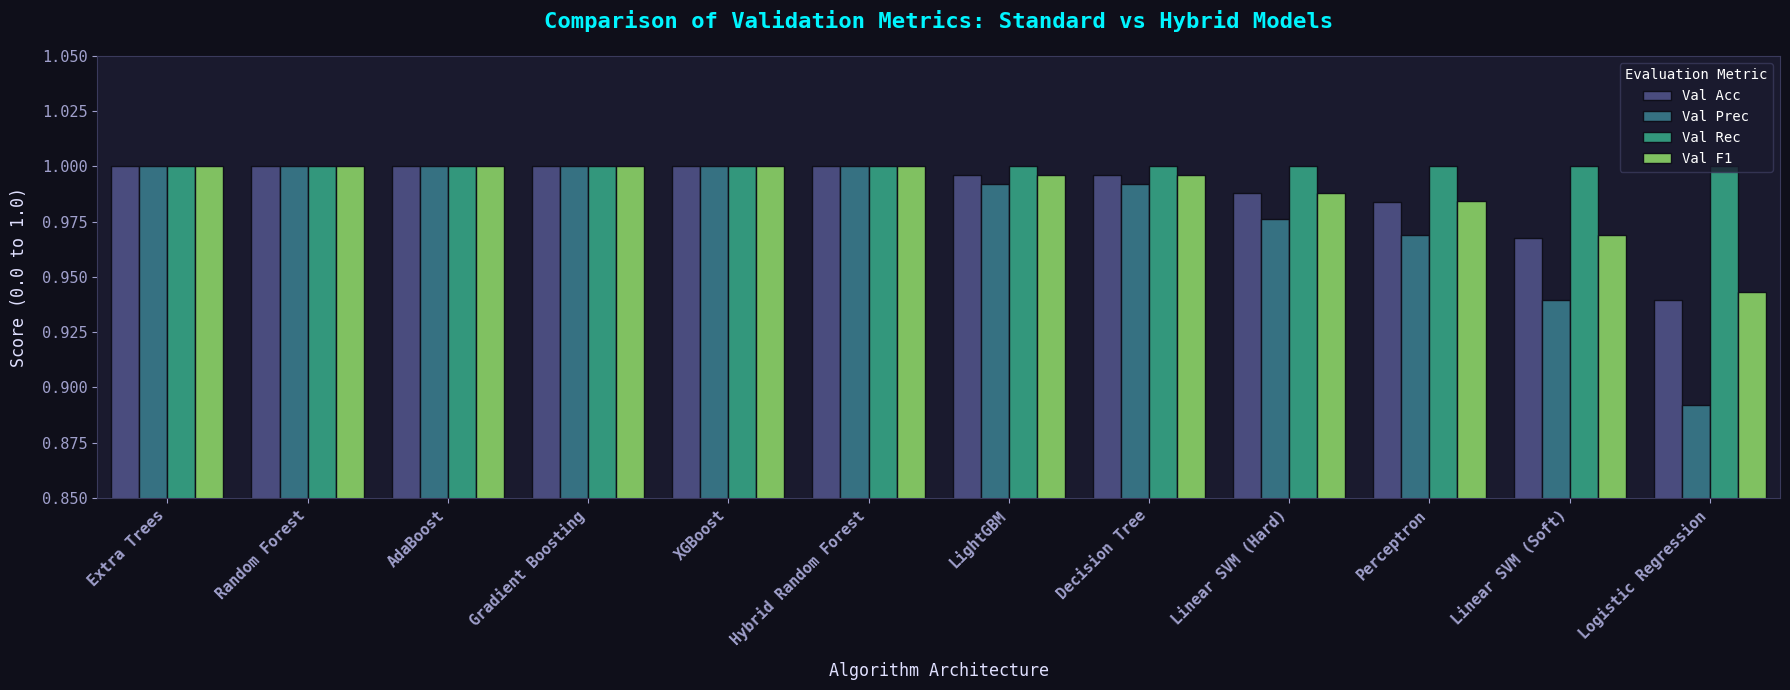

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score

print('=' * 80)
print('ULTIMATE MODEL METRICS VISUALIZATION (VALIDATION SET)')
print('=' * 80)
hybrid_val_prec = precision_score(y_val, hybrid_val_preds, average=multi_avg, zero_division=0)
hybrid_val_rec  = recall_score(y_val, hybrid_val_preds, average=multi_avg, zero_division=0)

hybrid_name = f"Hybrid {best_model_name}"
results[hybrid_name] = {
    'Val Acc' : round(hybrid_val_acc, 4),
    'Val Prec': round(hybrid_val_prec, 4),
    'Val Rec' : round(hybrid_val_rec, 4),
    'Val F1'  : round(hybrid_val_f1, 4)
}

plot_df = pd.DataFrame(results).T[['Val Acc', 'Val Prec', 'Val Rec', 'Val F1']].astype(float).reset_index()
plot_df = plot_df.rename(columns={'index': 'Model'})

plot_df = plot_df.sort_values(by='Val F1', ascending=False)
plot_df_melted = plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(18, 7))
ax = plt.gca()
ax.set_facecolor('#1a1a2e')
plt.gcf().patch.set_facecolor('#0f0f1a')
for spine in ax.spines.values():
    spine.set_color('#3a3a5c')

sns.barplot(
    data=plot_df_melted,
    x='Model',
    y='Score',
    hue='Metric',
    palette='viridis',
    edgecolor='#0f0f1a'
)

plt.title('Comparison of Validation Metrics: Standard vs Hybrid Models', color='#00f5ff', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Algorithm Architecture', color='#e0e0ff', fontsize=12, labelpad=10)
plt.ylabel('Score (0.0 to 1.0)', color='#e0e0ff', fontsize=12, labelpad=10)

plt.ylim(0.85, 1.05)

plt.xticks(rotation=45, ha='right', color='#a0a0cc', fontsize=11, fontweight='bold')
plt.yticks(color='#a0a0cc', fontsize=11)

legend = plt.legend(facecolor='#1a1a2e', edgecolor='#3a3a5c', labelcolor='white', title='Evaluation Metric')
legend.get_title().set_color('white')

plt.tight_layout()
plt.show()

FINAL TEST SET EVALUATION (THE VAULT)
 WINNING ARCHITECTURE : STANDARD Random Forest
   (Pure Supervised Algorithm)

Test Accuracy : 0.99598
Test F1-Score : 0.99595

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Class 0       0.99      1.00      1.00       125
     Class 1       1.00      0.99      1.00       124

    accuracy                           1.00       249
   macro avg       1.00      1.00      1.00       249
weighted avg       1.00      1.00      1.00       249



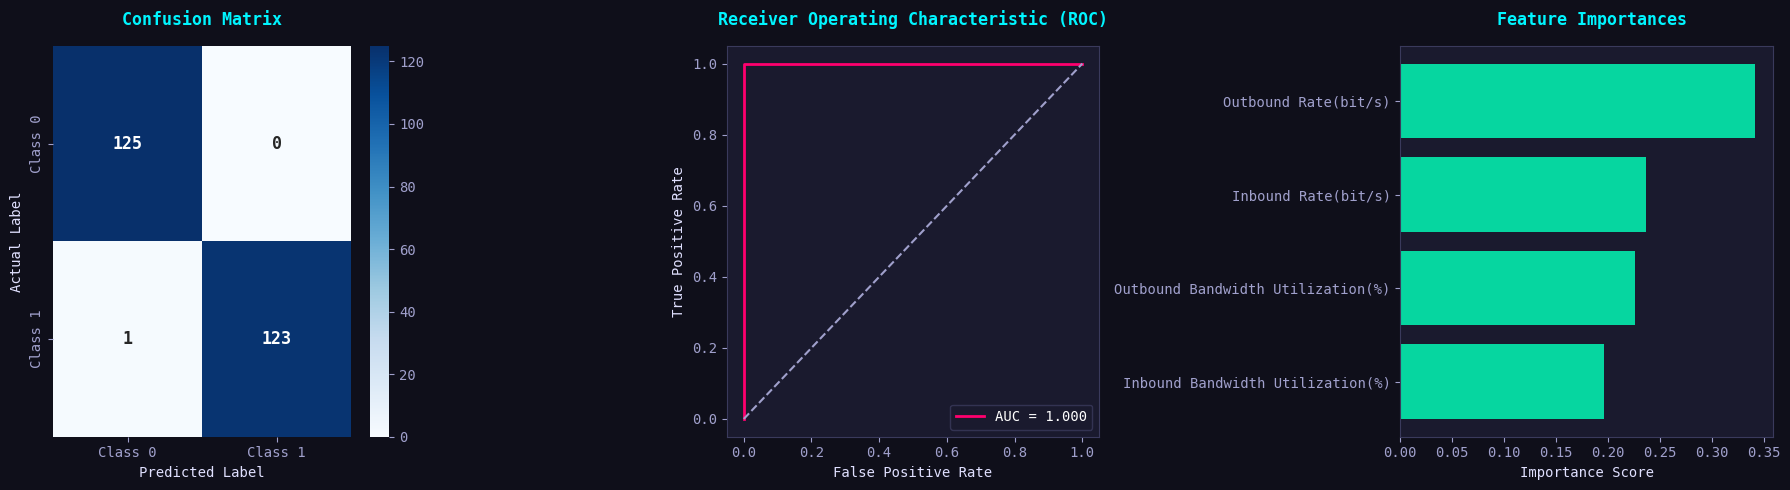

In [55]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('=' * 80)
print('FINAL TEST SET EVALUATION (THE VAULT)')
print('=' * 80)

if is_hybrid_final:
    test_clusters_col = kmeans.predict(X_test_sc).reshape(-1, 1)
    X_test_final = np.hstack((X_test_sc, test_clusters_col))
    print(f" WINNING ARCHITECTURE : HYBRID {best_model_name}")
    print("   (Supervised Algorithm combined with Unsupervised K-Means Features)\n")
else:
    X_test_final = X_test_sc
    print(f" WINNING ARCHITECTURE : STANDARD {best_model_name}")
    print("   (Pure Supervised Algorithm)\n")

final_test_preds = final_model.predict(X_test_final)
final_test_acc = accuracy_score(y_test, final_test_preds)
final_test_f1 = f1_score(y_test, final_test_preds, average=multi_avg, zero_division=0)

print(f"Test Accuracy : {final_test_acc:.5f}")
print(f"Test F1-Score : {final_test_f1:.5f}\n")
print("--- Detailed Classification Report ---")

try:
    class_names = [str(c) for c in le_target.classes_]
except NameError:
    class_names = [f"Class {c}" for c in np.unique(y_test)]

print(classification_report(y_test, final_test_preds, target_names=class_names))

has_probs = hasattr(final_model, "predict_proba")
if has_probs:
    y_score = final_model.predict_proba(X_test_final)
elif hasattr(final_model, "decision_function"):
    y_score = final_model.decision_function(X_test_final)
else:
    y_score = None
    print(" Notice: The selected model does not support probability estimates for ROC curves.")

fig = plt.figure(figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

ax1 = plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, final_test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax1,
            annot_kws={"size": 12, "weight": "bold"})
ax1.set_title('Confusion Matrix', color='#00f5ff', pad=15, fontweight='bold')
ax1.set_ylabel('Actual Label', color='#e0e0ff')
ax1.set_xlabel('Predicted Label', color='#e0e0ff')

ax2 = plt.subplot(1, 3, 2)
if y_score is not None:
    if is_binary:
        y_score_bin = y_score[:, 1] if len(y_score.shape) == 2 else y_score
        fpr, tpr, _ = roc_curve(y_test, y_score_bin)
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, color='#ff006e', lw=2, label=f'AUC = {roc_auc:.3f}')
    else:
        y_test_bin = label_binarize(y_test, classes=np.unique(y))
        for i in range(y_test_bin.shape[1]):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            ax2.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC: {auc(fpr, tpr):.2f})')

    ax2.plot([0, 1], [0, 1], color='#a0a0cc', lw=1.5, linestyle='--')
    ax2.set_title('Receiver Operating Characteristic (ROC)', color='#00f5ff', pad=15, fontweight='bold')
    ax2.set_xlabel('False Positive Rate', color='#e0e0ff')
    ax2.set_ylabel('True Positive Rate', color='#e0e0ff')
    ax2.legend(loc="lower right", facecolor='#1a1a2e', edgecolor='#3a3a5c', labelcolor='white')
else:
    ax2.text(0.5, 0.5, 'ROC Not Available\n(Model lacks predict_proba)', ha='center', va='center', color='#ff4d6d')

ax3 = plt.subplot(1, 3, 3)
if hasattr(final_model, 'feature_importances_'):
    try:
        feat_names = list(X.columns)
    except NameError:
        feat_names = [f"Feature {i}" for i in range(X_test_final.shape[1])]

    if is_hybrid_final and 'K-Means_Cluster_ID' not in feat_names:
        feat_names.append('K-Means_Cluster_ID')

    importances = final_model.feature_importances_
    indices = np.argsort(importances)[-10:]

    ax3.barh(range(len(indices)), importances[indices], color='#06d6a0', align='center')
    ax3.set_yticks(range(len(indices)))
    ax3.set_yticklabels([feat_names[i] for i in indices], color='#e0e0ff')
    ax3.set_title(' Feature Importances', color='#00f5ff', pad=15, fontweight='bold')
    ax3.set_xlabel('Importance Score', color='#e0e0ff')

elif y_score is not None and is_binary:
    y_score_bin = y_score[:, 1] if len(y_score.shape) == 2 else y_score
    precision, recall, _ = precision_recall_curve(y_test, y_score_bin)
    ap = average_precision_score(y_test, y_score_bin)

    ax3.plot(recall, precision, color='#06d6a0', lw=2, label=f'Avg Precision = {ap:.3f}')
    ax3.set_title('Precision-Recall Curve', color='#00f5ff', pad=15, fontweight='bold')
    ax3.set_xlabel('Recall', color='#e0e0ff')
    ax3.set_ylabel('Precision', color='#e0e0ff')
    ax3.legend(loc='lower left', facecolor='#1a1a2e', edgecolor='#3a3a5c', labelcolor='white')

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#1a1a2e')
    for spine in ax.spines.values():
        spine.set_color('#3a3a5c')
    ax.tick_params(colors='#a0a0cc')

plt.tight_layout()
plt.show()